In [51]:
import numpy as np
import scipy.stats as sc
import matplotlib.pyplot as plt

In [52]:
def left_prediction(X, z, sigma_est):
    return X.mean() - z * sigma_est

def right_prediction(X, z, sigma_est):
    return X.mean() + z * sigma_est

### Zadanie 4

In [53]:
alpha = 0.05
sigma = 0.2 # sigma znana
mu = 2.1

X = np.random.normal(mu, sigma, size=(1000, 1000))
n = 1000
z_norm = sc.norm.ppf(1 - alpha / 2)
means = np.mean(X, axis=1)

a = [left_prediction(x, z_norm, sigma/np.sqrt(n)) for x in means]
b = [right_prediction(x, z_norm, sigma/np.sqrt(n)) for x in means]
a = np.array(a)
b = np.array(b)

count = np.sum((a <= mu) & (mu <= b)) / n
print(count)

0.955


In [54]:
# sigma nieznana
n = 12
X = np.random.normal(mu, sigma, size=(1000, n))

means = np.mean(X, axis=1)
s = np.sqrt(np.var(X, axis=1, ddof=1)) # liczy odchylenie standardowe (estymator) - nieobciążony, dlatego ddof=1

z_student = sc.t.ppf(1 - alpha / 2, df=n-1) # parametr df oznacza 
means = np.mean(X, axis=1)

a = [left_prediction(means[i], z_student, s[i] / np.sqrt(n)) for i in range(1000)]
b = [right_prediction(means[i], z_student, s[i] / np.sqrt(n)) for i in range(1000)]
a = np.array(a)
b = np.array(b)

count = np.sum((a <= mu) & (mu <= b)) / 1000
print(count)


## (alternatywnie):
#a = means - z_student * s / np.sqrt(n)
#b = means + z_student * s / np.sqrt(n)

0.943


### Zadanie 5
Zbadaj symulacyjnie wpływ założenia normalności na przedziały ufności dla średniej. 

Wygeneruj 1000 prób długości n = 10, 30, 100 z rozkładu wykładniczego o wartości oczekiwanej 1.

Dla każdej próby wyznacz klasyczny 95% przedział ufności dla średniej oparty na rozkładzie t-Studenta.

In [55]:
alpha = 0.05
n = 10
X = np.random.exponential(size=(1000, n)) # długość grupy n=10
S = np.sqrt(np.var(X, axis=1, ddof=1))
means = np.mean(X, axis=1)
t_student = sc.t.ppf(1- alpha/2, df=n-1)

a = [left_prediction(means[i], z_student, S[i] / np.sqrt(n)) for i in range(1000)]
b = [right_prediction(means[i], z_student, S[i] / np.sqrt(n)) for i in range(1000)]
a = np.array(a)
b = np.array(b)

count = np.sum((a <= 1) & (1 <= b)) / 1000
print(count)

0.902


### Zadanie 6


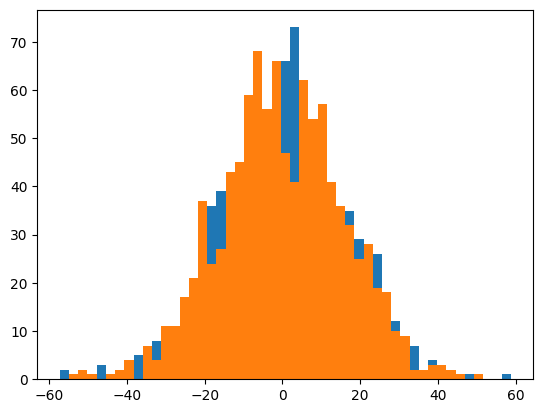

0.912
-2.3854931152366428 12.333879147328112


In [59]:
n = 1000
N = 10000
mu = 5
sigma = 5*np.pi

X = np.random.normal(mu, sigma, size=(n, N))
X_n1 = np.random.normal(mu, sigma, size=n)

Y_theory = np.random.normal(0, sigma*np.sqrt(1 + 1/n), size=n)
Y_emp = X_n1 - np.mean(X, axis=1)

bins = np.linspace(np.min([Y_theory, Y_emp]), np.max([Y_theory, Y_emp]), 50)
plt.hist(Y_emp, bins=bins)
plt.hist(Y_theory, bins=bins)
plt.show()

### przedział ufności
alpha = 0.1
z = sc.norm.ppf(1 - alpha/2)

a = np.array([left_prediction(x, z, sigma_est= sigma * np.sqrt(1 + 1/N)) for x in X])
b = np.array([right_prediction(x, z, sigma_est= sigma * np.sqrt(1 + 1/N)) for x in X])

count = np.sum((a <= X_n1) & (b >= X_n1)) / n
print(count)


### 6d.
sigma = np.sqrt(20)
N = 1000
X = np.random.normal(loc=mu, scale=sigma, size=N)
a_ = left_prediction(X, z=sc.norm.ppf(1-alpha/2), sigma_est=sigma*np.sqrt(1 + 1/N))
b_ = right_prediction(X, z=sc.norm.ppf(1-alpha/2), sigma_est=sigma*np.sqrt(1 + 1/N))
print(a_, b_)